
# **Polynomial Regression**

### Why Do We Need Polynomial Regression?

Simple Linear Regression works best when the relationship between the independent variable and the dependent variable is approximately linear.Because linear regression can still work on mildly non-linear data. In many real-world problems, however, the relationship between the variables is **non-linear**. In such cases, a straight line cannot accurately represent the data, leading to poor predictions and higher errors.

Polynomial Regression extends Linear Regression by transforming the original input feature into higher-degree polynomial features (such as (x^2), (x^3), etc.). This enables the model to fit curved relationships while still using the Linear Regression algorithm.

---

**Objective**

The objective of this practical is to create a **non-linear dataset** and compare the performance of:

* **Simple Linear Regression**
* **Polynomial Regression**

We will observe that a straight line is unable to fit the curved data properly, whereas Polynomial Regression generates a curved best-fit line that captures the underlying relationship more accurately.




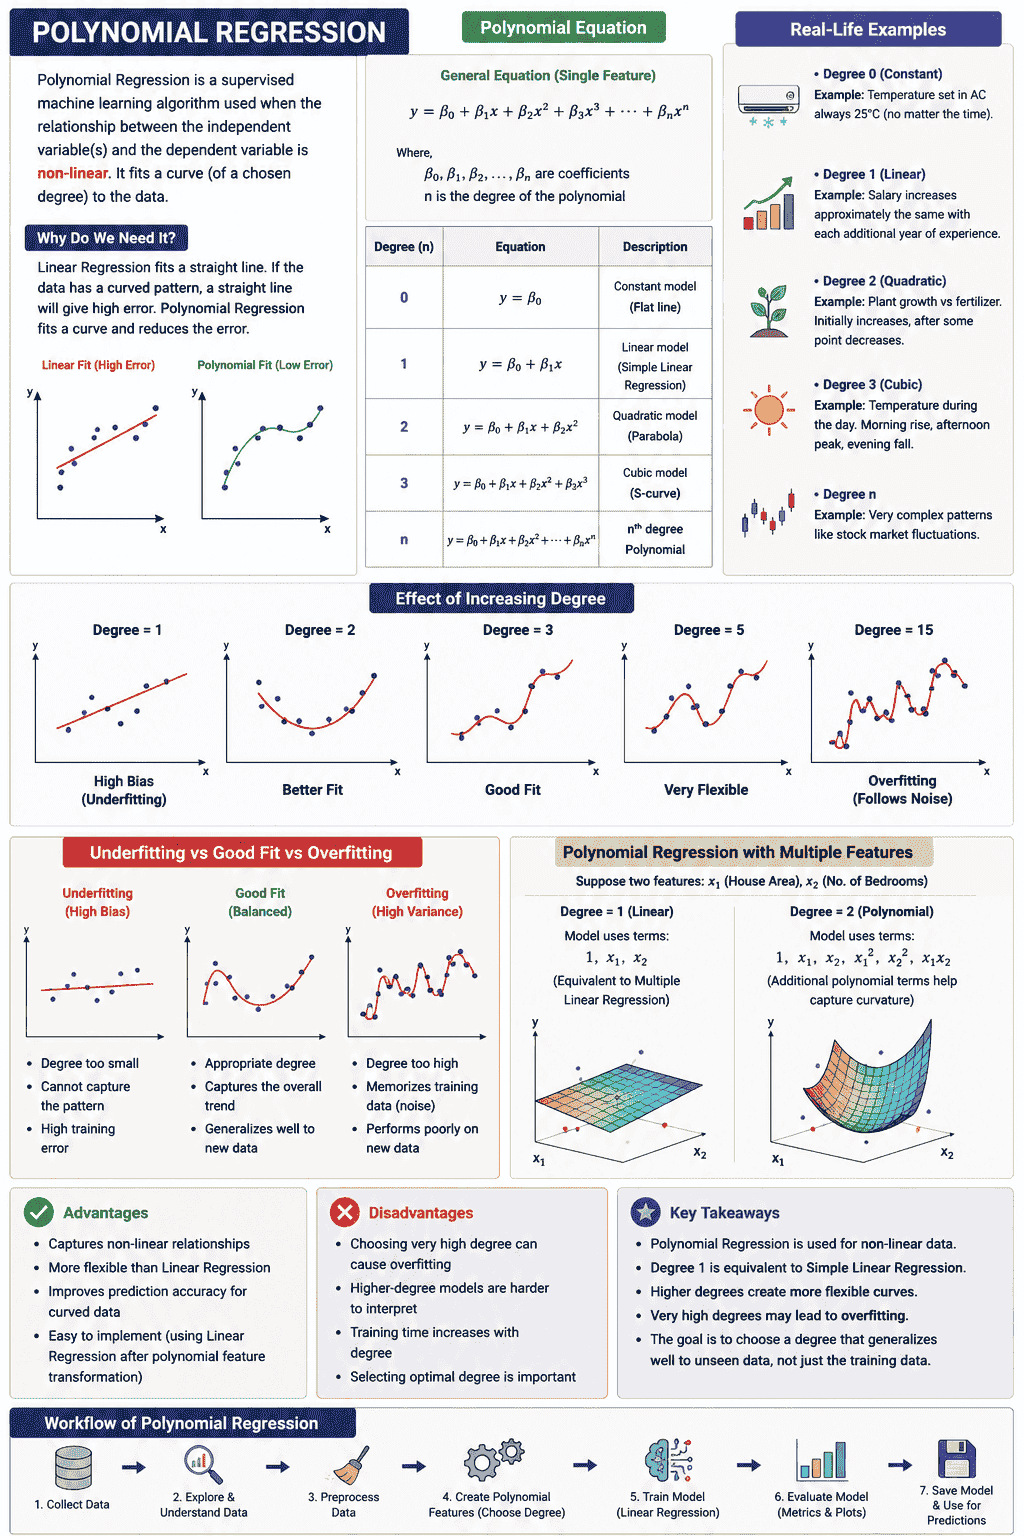

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## **Creating the Dataset**

**Understanding the Dataset**

Instead of using a real-world dataset, we create a **synthetic dataset** using **NumPy**.

The generated data follows a **quadratic equation**, which naturally produces a non-linear (quadratic) relationship between the input feature and the target variable.

The equation used is:

[
y = 0.5x^2 + 1.5x + 2 + Noise
]

where:

* **0.5x²** introduces the quadratic (curved) relationship.
* **1.5x** represents the linear component.
* **2** is the intercept.
* **Noise** represents random variations (outliers) added to make the dataset more realistic.


In [2]:
np.random.seed(42)
X = 6 * np.random.rand(100, 1) - 3

y = (
    0.5 * X**2
    + 1.5 * X
    + 2
    + np.random.randn(100, 1)
)

### **Understanding the Code**

**Creating the Input Feature (`X`)**

```python
X = 6 * np.random.rand(100, 1) - 3
```

* `np.random.rand(100, 1)` generates **100 random numbers** between **0 and 1**.
* Multiplying by **6** changes the range from **0–1** to **0–6**.
* Subtracting **3** shifts the values to the range **-3 to 3**.

Thus, the input feature `X` contains 100 randomly generated values between **-3 and 3**.

**Creating the Target Variable (`y`)**

```python
y = (
    0.5 * X**2
    + 1.5 * X
    + 2
    + np.random.randn(100, 1)
)
```

This follows the quadratic equation:

[
y = 0.5x^2 + 1.5x + 2
]

The final term,

```python
np.random.randn(100,1)
```

adds random Gaussian noise to simulate real-world data, where observations are rarely perfect.The Gaussian noise makes the dataset more realistic by introducing small random variations, similar to measurement errors found in real-world data.


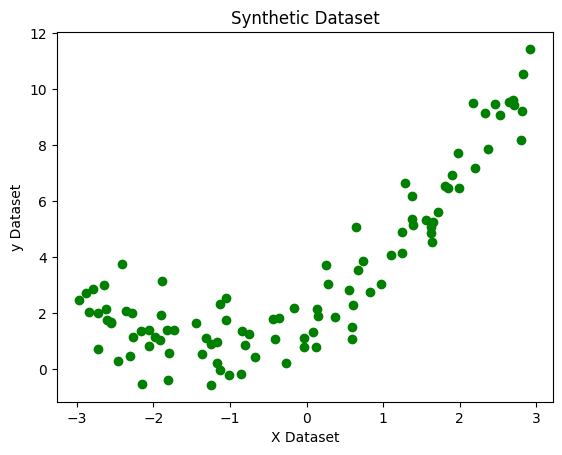

In [3]:
# Visualize the Dataset
plt.scatter(X, y, color='g')
plt.xlabel('X Dataset')
plt.ylabel('y Dataset')
plt.title('Synthetic Dataset')
plt.show()

**Observation**

The scatter plot clearly shows a curved relationship between X and y. Since the relationship is non-linear, a straight line may underfit the data.

Instead, it forms a curve, indicating that Simple Linear Regression may not perform well.

## **Train-Test Split**

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Apply Simple Linear Regression**

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
regression_1 = LinearRegression()

# Train the Model
regression_1.fit(X_train, y_train)

LinearRegression()

We are not applying feature scaling in this example because the input feature already lies within a small numerical range (approximately -3 to 3).

Polynomial Regression can work without scaling for small feature values. However, when feature values become very large or when using higher polynomial degrees, scaling is often recommended because polynomial terms (such as x^2,x^3,…) can become extremely large, which may affect numerical stability and optimization.





## **Making Predictions**
Once the model has been trained and validated, the next step is to make predictions on the test dataset.

In [7]:
y_pred = regression_1.predict(X_test)

## **Evaluating the Model Performance**

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
print("R² Score :", r2_score(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))

R² Score : 0.6870833008069619
MSE : 2.53424648082317


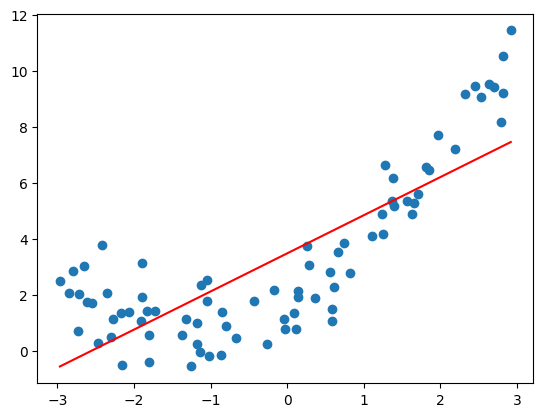

In [19]:
# Lets visualize this model
# plt.plot(X_train, regression_1.predict(X_train), color='r')
# plt.scatter(X_train, y_train)
# plt.xlabel('X Train')
# plt.ylabel('y Train')
# plt.title('Simple Linear Regression')
# plt.show()

idx = np.argsort(X_train[:,0])
plt.scatter(X_train, y_train)
plt.plot(
    X_train[idx],
    regression_1.predict(X_train)[idx],
    color="red"
)

The model produces a relatively high error because it attempts to fit a straight line to data that follows a curved relationship. To solve this problem, we use Polynomial Regression.

# **Apply Polynomial Transformation**

Linear Regression itself is still used. We simply create additional polynomial features before training the model.

We now transform the input feature.

If

```
X = x
```

Degree = 2

becomes

```
1
x
x²
```

Degree = 3

becomes

```
1
x
x²
x³
```

These new features allow Linear Regression to fit curves.

In [20]:
# Let's try Polynomial Regression with Degree = 2
from sklearn.preprocessing import PolynomialFeatures

In [21]:
poly = PolynomialFeatures(degree=2,include_bias=True)

include_bias=True adds a column of ones representing the intercept term.

In [22]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [23]:
X_train_poly

array([[ 1.00000000e+00,  2.53124541e+00,  6.40720333e+00],
       [ 1.00000000e+00,  2.32327646e+00,  5.39761349e+00],
       [ 1.00000000e+00, -1.80195731e+00,  3.24705014e+00],
       [ 1.00000000e+00, -2.79366887e+00,  7.80458577e+00],
       [ 1.00000000e+00,  2.92132162e+00,  8.53412001e+00],
       [ 1.00000000e+00, -1.89957294e+00,  3.60837736e+00],
       [ 1.00000000e+00, -2.26777059e+00,  5.14278345e+00],
       [ 1.00000000e+00,  1.36396976e-01,  1.86041351e-02],
       [ 1.00000000e+00,  1.24843547e+00,  1.55859111e+00],
       [ 1.00000000e+00, -2.96686730e+00,  8.80230156e+00],
       [ 1.00000000e+00,  2.81945911e+00,  7.94934969e+00],
       [ 1.00000000e+00,  1.20408127e-01,  1.44981171e-02],
       [ 1.00000000e+00, -1.04890007e+00,  1.10019135e+00],
       [ 1.00000000e+00,  5.54487413e-01,  3.07456291e-01],
       [ 1.00000000e+00,  3.67663185e-01,  1.35176218e-01],
       [ 1.00000000e+00, -2.06403288e+00,  4.26023172e+00],
       [ 1.00000000e+00, -2.15445465e+00

In [24]:
X_test_poly

array([[ 1.        , -2.6186499 ,  6.85732729],
       [ 1.        ,  2.3689641 ,  5.61199092],
       [ 1.        ,  1.63346862,  2.66821972],
       [ 1.        ,  0.97513371,  0.95088574],
       [ 1.        , -1.44732011,  2.0947355 ],
       [ 1.        , -0.35908504,  0.12894206],
       [ 1.        , -1.24713211,  1.5553385 ],
       [ 1.        ,  2.17862056,  4.74638752],
       [ 1.        , -2.87649303,  8.27421218],
       [ 1.        , -0.75275929,  0.56664654],
       [ 1.        , -0.40832989,  0.1667333 ],
       [ 1.        ,  0.64526911,  0.41637223],
       [ 1.        ,  1.89276857,  3.58257286],
       [ 1.        ,  2.69331322,  7.25393612],
       [ 1.        , -2.28243452,  5.20950736],
       [ 1.        , -2.06388816,  4.25963433],
       [ 1.        ,  1.62762208,  2.64915364],
       [ 1.        , -2.55573209,  6.53176651],
       [ 1.        ,  1.99465584,  3.97865194],
       [ 1.        , -1.97685526,  3.90795671]])

## **Train Polynomial Regression Model**

In [25]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly,y_train)

LinearRegression()

**Evaluate the Model**

In [26]:
from sklearn.metrics import r2_score
y_pred_poly = poly_model.predict(X_test_poly)
print("R² Score:", r2_score(y_test, y_pred_poly))

R² Score: 0.9214894267194649


Notice that Polynomial Regression achieves a much higher R² score, indicating that it captures the non-linear relationship more effectively than Simple Linear Regression.





In [27]:
print(poly_model.coef_)
print(poly_model.intercept_)

[[0.         1.44285051 0.56726223]]
[1.73625819]


**Visualize Polynomial Regression**

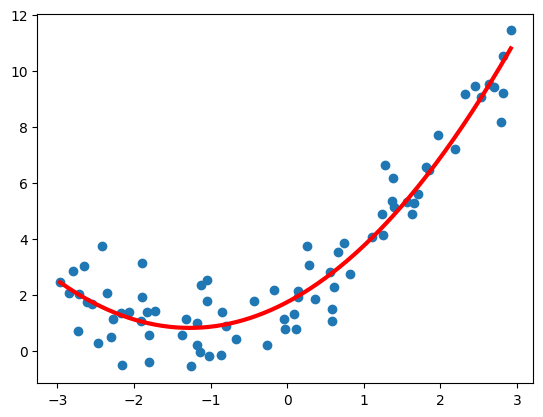

In [28]:
# plt.scatter(X_train, poly_model.predict(X_train_poly))
# plt.scatter(X_train, y_train)
# plt.xlabel('X Train')
# plt.ylabel('y Train')
# plt.title('Polynomial Regression')
# plt.show()

X_new = np.linspace(
    X.min(),
    X.max(),
    200
).reshape(-1,1)

X_new_poly = poly.transform(X_new)
y_new = poly_model.predict(X_new_poly)
plt.scatter(X_train,y_train)
plt.plot(
    X_new,
    y_new,
    color="red",
    linewidth=3
)


# **Creating Polynomial Features (Degree = 3)**

Simple Linear Regression can only learn a straight-line relationship: y = b₀ + b₁x

To learn a curved relationship, we create new features from the original feature.

For **Degree = 3**, each value of **x** is converted into: `1, x, x^2, x^3`

These new features allow Linear Regression to fit a cubic curve.

In [30]:
# Create a PolynomialFeatures object with degree = 3
poly3 = PolynomialFeatures(
    degree=3,
    include_bias=True
)

**Explanation**

* `degree=3` tells sklearn to create features up to (x^3).
* `include_bias=True` adds a column of **1s**.
* The column of **1s** represents the intercept (bias) term.

For example,

Original X

```text
2
```

becomes

```text
[1, 2, 4, 8]
```

because

```text
1
x
x²
x³
```

In [31]:
# Transform the Training Data
X_train_poly3 = poly3.fit_transform(X_train)

## **Explanation**

This line performs **two operations**:

### 1. fit()

Learns how polynomial features should be generated.

Since our data has only **one feature**, it simply learns:

> "I need to create features up to degree 3."

### 2. transform()

Actually converts

```text
x
```

into

```text
[1, x, x², x³]
```

For example

| Original X | After Transformation |
| ---------- | -------------------- |
| 2          | [1, 2, 4, 8]         |
| 3          | [1, 3, 9, 27]        |
| 5          | [1, 5, 25, 125]      |


In [32]:
# Transform the Test Data
X_test_poly3 = poly3.transform(X_test)

In [33]:
# Verify the Transformation

print("Original X_train shape :", X_train.shape)
print("Polynomial X_train shape :", X_train_poly3.shape)

print("\nFirst 5 original values:")
print(X_train[:5])

print("\nFirst 5 transformed values:")
print(X_train_poly3[:5])

Original X_train shape : (80, 1)
Polynomial X_train shape : (80, 4)

First 5 original values:
[[ 2.53124541]
 [ 2.32327646]
 [-1.80195731]
 [-2.79366887]
 [ 2.92132162]]

First 5 transformed values:
[[  1.           2.53124541   6.40720333  16.21820401]
 [  1.           2.32327646   5.39761349  12.54014833]
 [  1.          -1.80195731   3.24705014  -5.85104572]
 [  1.          -2.79366887   7.80458577 -21.80342835]
 [  1.           2.92132162   8.53412001  24.93090928]]


## **Train the Model**

Although we call `LinearRegression()`, this is **Polynomial Regression** because we are training the model on **polynomial features** instead of the original feature.

Earlier, we transformed: x → [1, x, x^2, x^3]

Now, Linear Regression learns the relationship using these new features.

In [34]:
poly_model3 = LinearRegression()

poly_model3.fit(X_train_poly3, y_train)

LinearRegression()

Important: Although we are using LinearRegression(), this is still Polynomial Regression because the model is trained on polynomial features (x, x², x³) rather than the original feature.

## **Explanation**

* `LinearRegression()` creates the regression model.
* `fit()` trains the model using the transformed polynomial features.
* The model learns the coefficients for:

  * Intercept
  * (x)
  * (x^2)
  * (x^3)

Instead of learning : y=b0 +b1 * x


it now learns : y = b0 +b1 * x + b2 * x^2 + b3 * x^3


This equation can fit a curved relationship.

In [35]:
# Make Predictions
y_pred_poly3 = poly_model3.predict(X_test_poly3)

The trained model predicts the target values for the **test data** using the polynomial features.

Notice that we pass:

```python
X_test_poly3
```

and **not**

```python
X_test
```

because the model was trained using polynomial features. The input during prediction must have the same structure as the training data.


In [36]:
# Evaluate the Model
print("R² Score:", r2_score(y_test, y_pred_poly3))

R² Score: 0.9207228021072423


The R² Score measures how well the model explains the variation in the target variable.

Since the dataset follows a curved relationship, the Degree 3 Polynomial Regression model should achieve a much higher R² score than Simple Linear Regression.

In [37]:
print("MSE :", mean_squared_error(y_test, y_pred_poly3))

MSE : 0.6420493386493995


## **Create New Input Data**

**Create New Input Data for Visualization**

To draw a **smooth polynomial curve**, we need many evenly spaced input values.

The training data contains only a limited number of points, which would produce a rough or broken-looking curve.

Using `np.linspace()` creates many evenly spaced values across the entire range of the dataset.

In [38]:
# Create 200 evenly spaced values between -3 and 3
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new

array([[-3.        ],
       [-2.96984925],
       [-2.93969849],
       [-2.90954774],
       [-2.87939698],
       [-2.84924623],
       [-2.81909548],
       [-2.78894472],
       [-2.75879397],
       [-2.72864322],
       [-2.69849246],
       [-2.66834171],
       [-2.63819095],
       [-2.6080402 ],
       [-2.57788945],
       [-2.54773869],
       [-2.51758794],
       [-2.48743719],
       [-2.45728643],
       [-2.42713568],
       [-2.39698492],
       [-2.36683417],
       [-2.33668342],
       [-2.30653266],
       [-2.27638191],
       [-2.24623116],
       [-2.2160804 ],
       [-2.18592965],
       [-2.15577889],
       [-2.12562814],
       [-2.09547739],
       [-2.06532663],
       [-2.03517588],
       [-2.00502513],
       [-1.97487437],
       [-1.94472362],
       [-1.91457286],
       [-1.88442211],
       [-1.85427136],
       [-1.8241206 ],
       [-1.79396985],
       [-1.7638191 ],
       [-1.73366834],
       [-1.70351759],
       [-1.67336683],
       [-1

**Explanation**

```python
np.linspace(-3, 3, 200)
```

creates **200 equally spaced numbers** between **-3** and **3**.

Example:

```text
[-3.00,
 -2.97,
 -2.94,
 ...
 2.94,
 2.97,
 3.00]
```

Then,

```python
.reshape(200, 1)
```

converts the array into a **2D array** with:

* **200 rows**
* **1 column**

This is required because Scikit-learn expects the input features to be two-dimensional.

In [44]:
# Convert to Polynomial Features
X_new_poly3 = poly3.transform(X_new)
y_new_poly3 = poly_model3.predict(X_new_poly3)
X_new_poly3

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

The model was trained using **polynomial features**, not the original feature.

Therefore, before making predictions, we must transform the new input data in the same way.

For a **Degree = 2** model:

| Original X | After Transformation |
| ---------- | -------------------- |
| 2          | [1, 2, 4]            |
| 3          | [1, 3, 9]            |
| 5          | [1, 5, 25]           |

If the model were trained with **Degree = 3**, the transformation would be:

| Original X | After Transformation |
| ---------- | -------------------- |
| 2          | [1, 2, 4, 8]         |
| 3          | [1, 3, 9, 27]        |




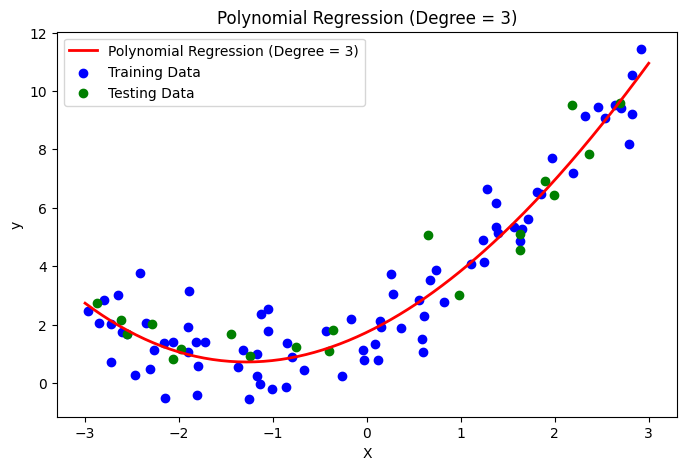

In [46]:
X_new_poly3 = poly3.transform(X_new)
y_new_poly3 = poly_model3.predict(X_new_poly3)

# Visualize the Results

plt.figure(figsize=(8,5))

# Plot the polynomial regression curve
plt.plot(
    X_new,
    y_new_poly3,
    color="red",
    linewidth=2,
    label="Polynomial Regression (Degree = 3)"
)

# Plot training data
plt.scatter(
    X_train,
    y_train,
    color="blue",
    label="Training Data"
)

# Plot testing data
plt.scatter(
    X_test,
    y_test,
    color="green",
    label="Testing Data"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression (Degree = 3)")
plt.legend()

plt.show()


**Conclusion**
>
> * Degree 1 (Simple Linear Regression) underfits the curved data.
> * Degree 2 captures the quadratic relationship much better.
> * Degree 3 fits the data even more closely.
> * Increasing the polynomial degree too much can eventually lead to overfitting.